# Практическое занятие №2: Градиентный спуск и оптимизаторы
**Цели занятия:**
- Научиться визуализировать функции потерь двух переменных (3D и линии уровня).
- Реализовать простой градиентный спуск (SGD) с помощью PyTorch и проследить траекторию оптимизации.
- Познакомиться с основными оптимизаторами из семейства gradient descent: SGD с моментом, RMSprop, Adam.
- Исследовать влияние скорости обучения (learning rate) на сходимость.

Слова "**Задание**" выделены жирным шрифтом по тексту.

## 1. Импорт необходимых библиотек
Установка и импорт:
- `torch` для автоматического дифференцирования и оптимизаторов.
- `numpy` для численных операций.
- `matplotlib` для построения графиков (3D, контурные, анимация).
- `ipywidgets` (опционально) для интерактивности.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import animation
from IPython.display import HTML
import warnings
warnings.filterwarnings('ignore')

# Для воспроизводимости
torch.manual_seed(42)
np.random.seed(42)

## 2. Функции для визуализации
Определим две классические тестовые функции:
- **Функция Розенброка** (Rosenbrock) — «овражная» функция, сложная для оптимизации:
  $$f(x,y) = (a - x)^2 + b\,(y - x^2)^2,\quad a=1,\; b=100.$$
  Глобальный минимум в точке $(1,1)$.
- **Функция Химмельблау** (Himmelblau) — с несколькими локальными минимумами:
  $$f(x,y) = (x^2 + y - 11)^2 + (x + y^2 - 7)^2.$$
  Четыре локальных минимума: $(3,2)$, $(-2.805,3.131)$, $(-3.779,-3.283)$, $(3.584,-1.848)$.

In [2]:
def rosenbrock(x, y, a=1, b=100):
    return (a - x)**2 + b * (y - x**2)**2

def himmelblau(x, y):
    return (x**2 + y - 11)**2 + (x + y**2 - 7)**2

# Создадим сетку для построения графиков
x = np.linspace(-2, 2, 100)
y = np.linspace(-1, 3, 100)
X, Y = np.meshgrid(x, y)
Z_rosen = rosenbrock(X, Y)

# Для Химмельблау возьмём более широкий диапазон
x_h = np.linspace(-5, 5, 100)
y_h = np.linspace(-5, 5, 100)
X_h, Y_h = np.meshgrid(x_h, y_h)
Z_himm = himmelblau(X_h, Y_h)

### 2.1 3D-визуализация функций
**Задание 1**: построить поверхности функций Розенброка и Химмельблау в 3D с возможностью интерактивного вращения. Обратите внимание на овраг у Розенброка и несколько впадин у Химмельблау.

Пример можно взять из лекции (библиотека plotly).

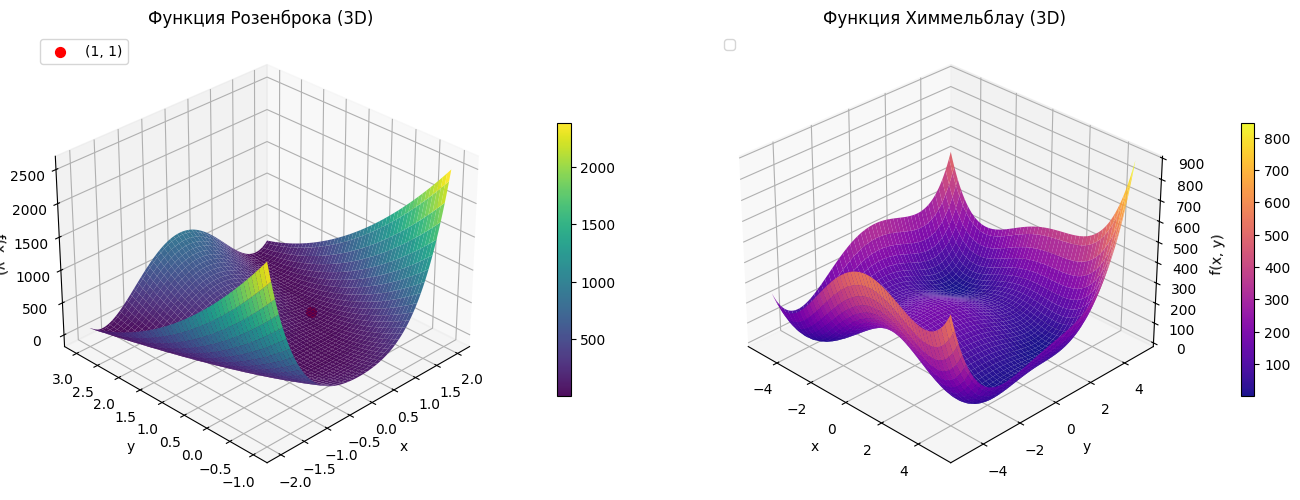

In [3]:
# Задание 1: 3D-визуализация поверхностей
fig = plt.figure(figsize=(14, 5))

# Розенброк
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf1 = ax1.plot_surface(X, Y, Z_rosen, cmap='viridis', linewidth=0, antialiased=True, alpha=0.95)
ax1.scatter(1, 1, rosenbrock(1, 1), color='red', s=50, label='(1, 1)')
ax1.set_title('Функция Розенброка (3D)')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('f(x, y)')
ax1.view_init(elev=30, azim=-135)
ax1.legend(loc='upper left')
fig.colorbar(surf1, ax=ax1, shrink=0.6, pad=0.1)

# Химмельблау
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf2 = ax2.plot_surface(X_h, Y_h, Z_himm, cmap='plasma', linewidth=0, antialiased=True, alpha=0.95)
ax2.set_title('Функция Химмельблау (3D)')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_zlabel('f(x, y)')
ax2.view_init(elev=30, azim=-45)
ax2.legend(loc='upper left')
fig.colorbar(surf2, ax=ax2, shrink=0.6, pad=0.1)

plt.tight_layout()
plt.show()

### 2.2 Контурные графики (линии уровня)
**Задание 2.** Нарисовать контурные графиках и точки глобальных (или локальных) минимумов на них.
Можно matplotlib или seaborn. (Проявить фантазию в оформлении!)

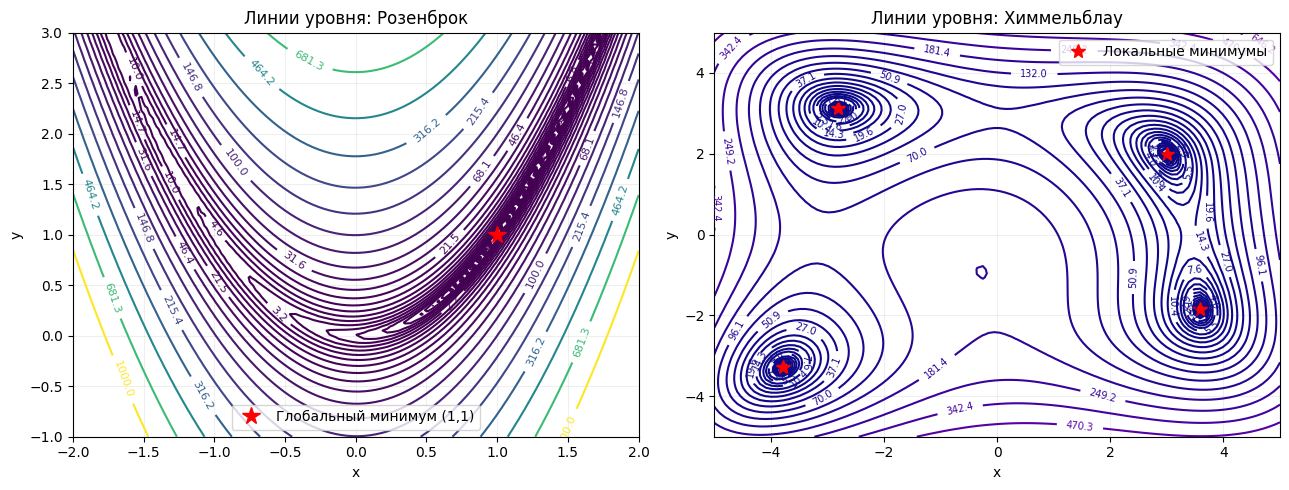

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Минимумы Химмельблау используем дальше в заданиях
minima = [(3.0, 2.0), (-2.805, 3.131), (-3.779, -3.283), (3.584, -1.848)]

# Контуры Розенброка
levels_rosen = np.logspace(-1, 3, 25)
cs1 = axes[0].contour(X, Y, Z_rosen, levels=levels_rosen, cmap='viridis')
axes[0].clabel(cs1, inline=True, fontsize=8, fmt='%.1f')
axes[0].plot(1, 1, 'r*', markersize=13, label='Глобальный минимум (1,1)')
axes[0].set_title('Линии уровня: Розенброк')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].legend()
axes[0].grid(alpha=0.2)

# Контуры Химмельблау
levels_himm = np.logspace(-0.5, 3.5, 30)
cs2 = axes[1].contour(X_h, Y_h, Z_himm, levels=levels_himm, cmap='plasma')
axes[1].clabel(cs2, inline=True, fontsize=7, fmt='%.1f')
for i, (mx, my) in enumerate(minima):
    label = 'Локальные минимумы' if i == 0 else None
    axes[1].plot(mx, my, 'r*', markersize=10, label=label)
axes[1].set_title('Линии уровня: Химмельблау')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].legend(loc='upper right')
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

**Задание 3.** Изучите полученные графики. Почему функция Розенброка считается сложной для градиентного спуска? (Ответьте в ячейке ниже)

*Ваш ответ:*
Функция Розенброка сложна для градиентного спуска из-за узкого и изогнутого «оврага»: в одном направлении поверхность очень крутая, а в другом почти плоская.
Из-за этого шаги алгоритма часто дают зигзагообразную траекторию, и без аккуратного подбора learning rate (или более продвинутого оптимизатора) сходимость получается медленной и неустойчивой.

## 3. Реализация градиентного спуска (SGD) с помощью PyTorch

Будем минимизировать функцию двух переменных, используя автоматическое дифференцирование PyTorch. Создадим тензоры с включённым `requires_grad=True` и на каждом шаге будем обновлять их с помощью правила SGD:
$$\theta_{t+1} = \theta_t - \eta \nabla f(\theta_t).$$

В цикле оптимизации необходимо:
1. Вычислить значение функции.
2. Вызвать `.backward()` для вычисления градиентов.
3. Обновить параметры вручную (или с помощью оптимизатора).
4. Обнулить градиенты (`.grad.zero_()`).

Напишем функцию, которая выполняет заданное количество шагов SGD и записывает траекторию.

In [5]:
def sgd_trajectory(func, x0, y0, lr=0.01, steps=50):
    """
    Выполняет SGD для функции func(x,y) от двух переменных.
    Возвращает списки x_hist, y_hist, f_hist.
    """
    x = torch.tensor(x0, requires_grad=True, dtype=torch.float32)
    y = torch.tensor(y0, requires_grad=True, dtype=torch.float32)

    x_hist, y_hist, f_hist = [], [], []

    for i in range(steps):
        # Вычисляем функцию
        f = func(x, y)
        # Сохраняем историю (отсоединяем от графа вычислений)
        x_hist.append(x.item())
        y_hist.append(y.item())
        f_hist.append(f.item())

        # Градиенты
        f.backward()

        # Обновление вручную (SGD)
        with torch.no_grad():
            x -= lr * x.grad
            y -= lr * y.grad

        # Обнуляем градиенты
        x.grad.zero_()
        y.grad.zero_()

    return x_hist, y_hist, f_hist

Протестируем на функции Розенброка с начальной точкой (-1.5, 1.5), learning rate = 0.001 и 200 шагов. Построим траекторию на контурном графике.

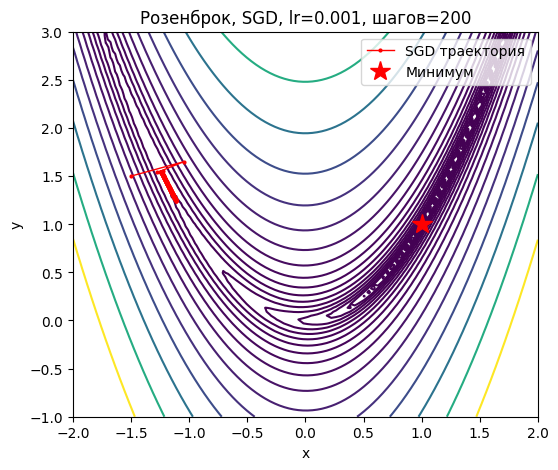

In [6]:
x0, y0 = -1.5, 1.5
lr = 0.001
steps = 200

x_hist, y_hist, f_hist = sgd_trajectory(rosenbrock, x0, y0, lr, steps)

# Визуализация
plt.figure(figsize=(6,5))
plt.contour(X, Y, Z_rosen, levels=np.logspace(-1, 3, 20), cmap='viridis')
plt.plot(x_hist, y_hist, 'r.-', markersize=4, linewidth=1, label='SGD траектория')
plt.plot(1, 1, 'r*', markersize=15, label='Минимум')
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'Розенброк, SGD, lr={lr}, шагов={steps}')
plt.legend()
plt.show()

**Задание 4.** Поэкспериментируйте с learning rate и начальной точкой. Попробуйте для обеих функций:
- Попробовать 5 различных значений learning rate (например, 0.01, 0.05). Что происходит?
- Попробовать 5 различных начальных точек, например (0, 2) или (-1, -1) или случаным образом выбранных, надётся ли действительный глобальный минимум?

Результирующие графики всех экспериментов сохраните в отчётном блокноте.



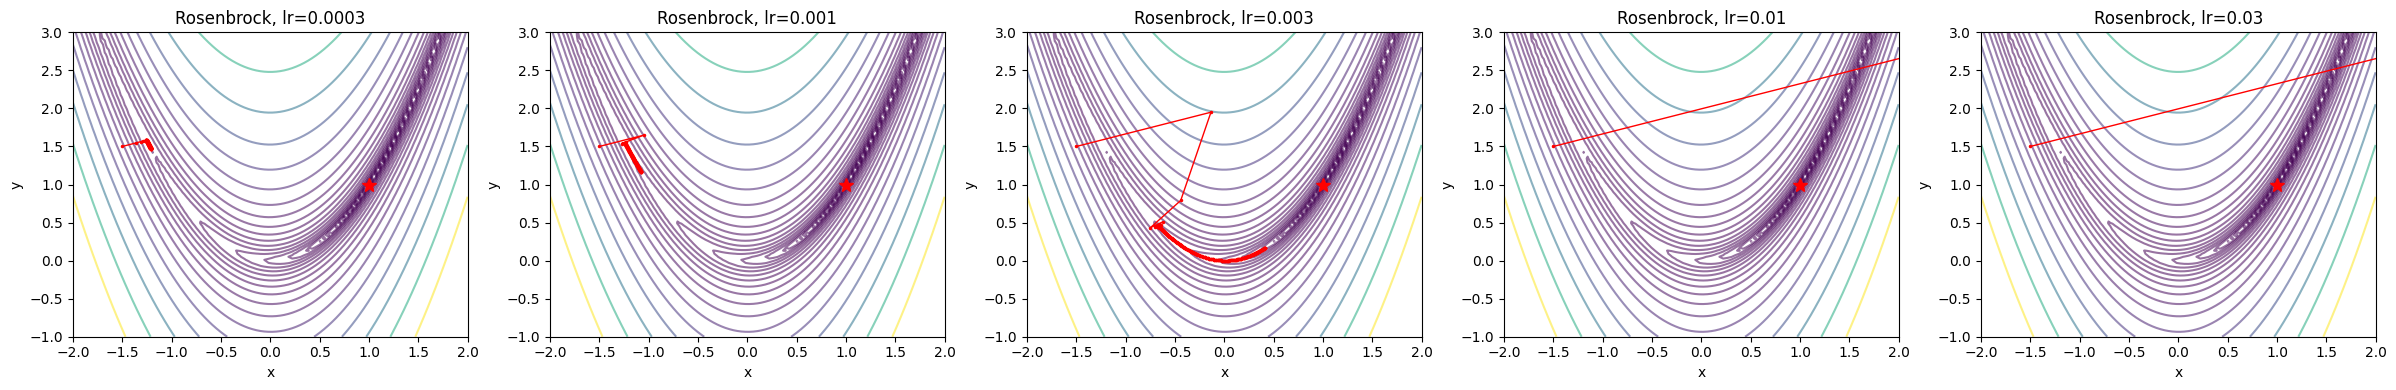

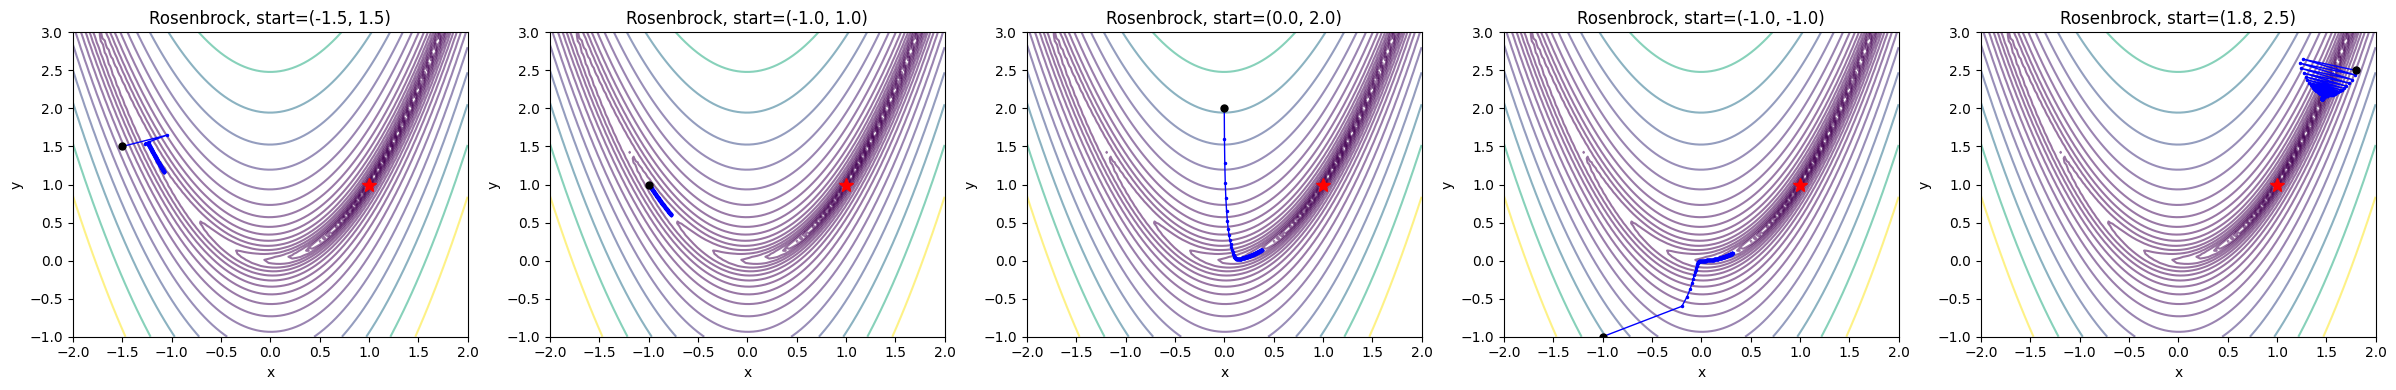

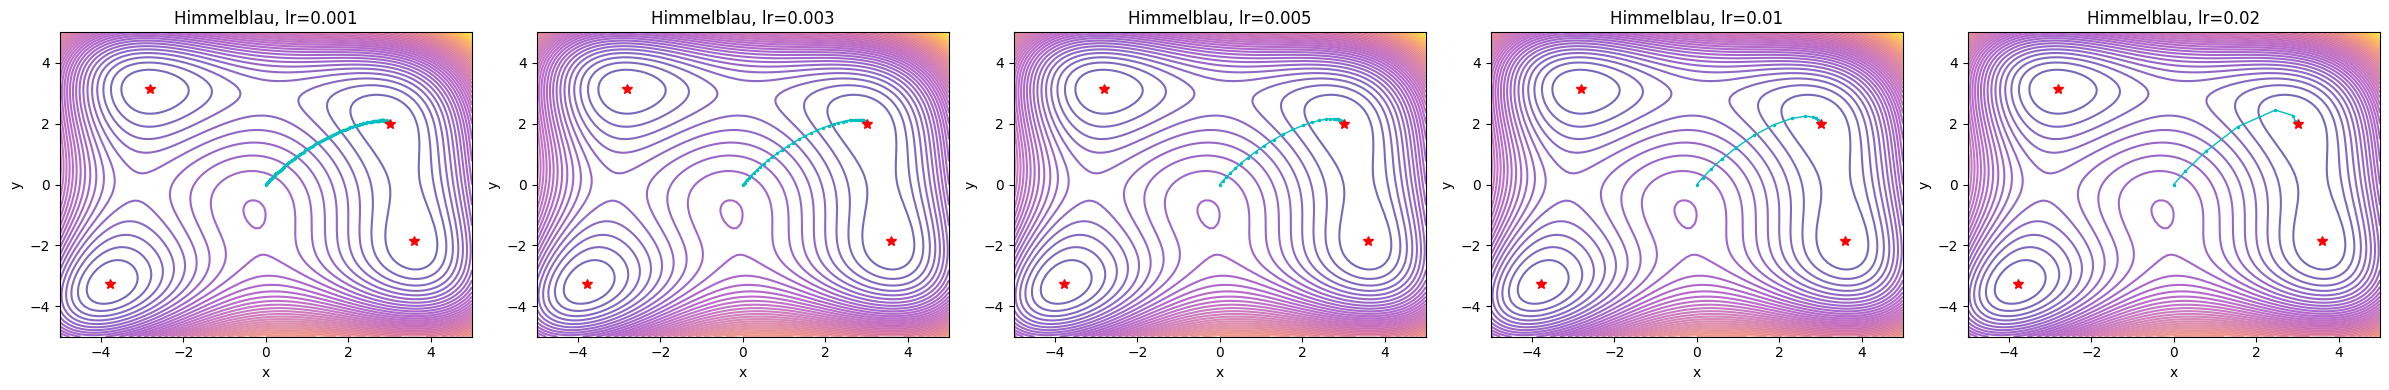

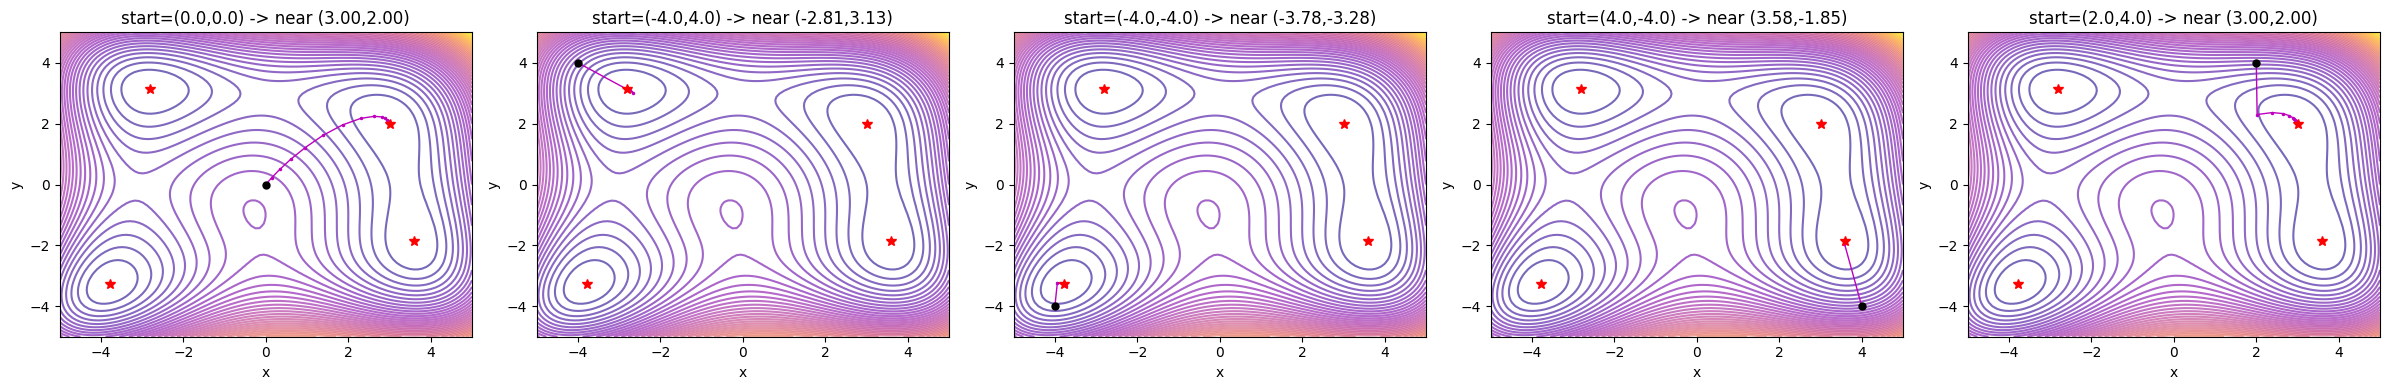

In [7]:
# Задание 4: эксперименты с learning rate и начальными точками для обеих функций

def nearest_himmelblau_minimum(x_last, y_last, minima_points):
    dists = [np.sqrt((x_last - mx) ** 2 + (y_last - my) ** 2) for mx, my in minima_points]
    idx = int(np.argmin(dists))
    return minima_points[idx], dists[idx]

# 1) Розенброк: 5 значений learning rate
lr_values_rosen = [0.0003, 0.001, 0.003, 0.01, 0.03]
start_rosen = (-1.5, 1.5)
steps_rosen = 250

fig, axes = plt.subplots(1, 5, figsize=(24, 4))
for i, lr_cur in enumerate(lr_values_rosen):
    xh, yh, fh = sgd_trajectory(rosenbrock, start_rosen[0], start_rosen[1], lr=lr_cur, steps=steps_rosen)
    ax = axes[i]
    ax.contour(X, Y, Z_rosen, levels=np.logspace(-1, 3, 20), cmap='viridis', alpha=0.55)
    ax.plot(xh, yh, 'r.-', markersize=3, linewidth=1)
    ax.plot(1, 1, 'r*', markersize=10)
    ax.set_title(f'Rosenbrock, lr={lr_cur}')
    ax.set_xlim(-2, 2)
    ax.set_ylim(-1, 3)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
plt.tight_layout()
plt.show()

# 2) Розенброк: 5 начальных точек
start_points_rosen = [(-1.5, 1.5), (-1.0, 1.0), (0.0, 2.0), (-1.0, -1.0), (1.8, 2.5)]
lr_rosen_fixed = 0.001

fig, axes = plt.subplots(1, 5, figsize=(24, 4))
for i, (x0r, y0r) in enumerate(start_points_rosen):
    xh, yh, fh = sgd_trajectory(rosenbrock, x0r, y0r, lr=lr_rosen_fixed, steps=steps_rosen)
    ax = axes[i]
    ax.contour(X, Y, Z_rosen, levels=np.logspace(-1, 3, 20), cmap='viridis', alpha=0.55)
    ax.plot(xh, yh, 'b.-', markersize=3, linewidth=1)
    ax.plot(x0r, y0r, 'ko', markersize=5)
    ax.plot(1, 1, 'r*', markersize=10)
    ax.set_title(f'Rosenbrock, start=({x0r}, {y0r})')
    ax.set_xlim(-2, 2)
    ax.set_ylim(-1, 3)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
plt.tight_layout()
plt.show()

# 3) Химмельблау: 5 значений learning rate
lr_values_himm = [0.001, 0.003, 0.005, 0.01, 0.02]
start_himm = (0.0, 0.0)
steps_himm = 220

fig, axes = plt.subplots(1, 5, figsize=(24, 4))
for i, lr_cur in enumerate(lr_values_himm):
    xh, yh, fh = sgd_trajectory(himmelblau, start_himm[0], start_himm[1], lr=lr_cur, steps=steps_himm)
    ax = axes[i]
    ax.contour(X_h, Y_h, Z_himm, levels=50, cmap='plasma', alpha=0.6)
    ax.plot(xh, yh, 'c.-', markersize=3, linewidth=1)
    for j, (mx, my) in enumerate(minima):
        label = 'Минимумы' if j == 0 else None
        ax.plot(mx, my, 'r*', markersize=7, label=label)
    ax.set_title(f'Himmelblau, lr={lr_cur}')
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
plt.tight_layout()
plt.show()

# 4) Химмельблау: 5 начальных точек
start_points_himm = [(0.0, 0.0), (-4.0, 4.0), (-4.0, -4.0), (4.0, -4.0), (2.0, 4.0)]
lr_himm_fixed = 0.01

fig, axes = plt.subplots(1, 5, figsize=(24, 4))
for i, (x0h, y0h) in enumerate(start_points_himm):
    xh, yh, fh = sgd_trajectory(himmelblau, x0h, y0h, lr=lr_himm_fixed, steps=steps_himm)
    (mx, my), dist = nearest_himmelblau_minimum(xh[-1], yh[-1], minima)

    ax = axes[i]
    ax.contour(X_h, Y_h, Z_himm, levels=50, cmap='plasma', alpha=0.6)
    ax.plot(xh, yh, 'm.-', markersize=3, linewidth=1)
    ax.plot(x0h, y0h, 'ko', markersize=5)
    for j, (mxx, myy) in enumerate(minima):
        label = 'Минимумы' if j == 0 else None
        ax.plot(mxx, myy, 'r*', markersize=7, label=label)
    ax.set_title(f'start=({x0h},{y0h}) -> near ({mx:.2f},{my:.2f})')
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    ax.set_xlabel('x')
    ax.set_ylabel('y')

plt.tight_layout()
plt.show()

## 4. Сравнение оптимизаторов из torch.optim

PyTorch предоставляет готовые реализации многих оптимизаторов: SGD (с momentum и nesterov), RMSprop, Adam и др. Мы можем использовать их, передав параметры модели. В нашем случае модель — это просто два тензора x и y.

Напишем функцию, которая принимает оптимизатор (например, `torch.optim.SGD`), его параметры и возвращает траекторию.

In [8]:
def optimizer_trajectory(func, x0, y0, optim_class, optim_kwargs, steps=100):
    """
    Метод для конкретного оптимизатора и конкретной оптимизируемой функции реализует градиентный спуск.
    optim_class: наименование класса оптимизатора строкой (SGD, Adam, RMSprop)
    optim_kwargs: словарь параметров, например {'lr':0.01, 'momentum':0.9}
    """
    x = torch.tensor(x0, requires_grad=True, dtype=torch.float32)
    y = torch.tensor(y0, requires_grad=True, dtype=torch.float32)

    # Создаём оптимизатор, передав список параметров
    optimizer = optim_class([x, y], **optim_kwargs)

    x_hist, y_hist, f_hist = [], [], []

    for i in range(steps):
        optimizer.zero_grad()
        f = func(x, y)
        f.backward()
        # собственно обновление значений подбираемых параметров
        optimizer.step()

        x_hist.append(x.item())
        y_hist.append(y.item())
        f_hist.append(f.item())

    return x_hist, y_hist, f_hist

### 4.1 Сравнение на функции Розенброка
Возьмём начальную точку (-1.5, 1.5), 100 шагов, и сравним:
- SGD (learning rate = 0.001)
- SGD с моментом (lr=0.001, momentum=0.9)
- RMSprop (lr=0.01)
- Adam (lr=0.01)

Построим все траектории на одном контурном графике.

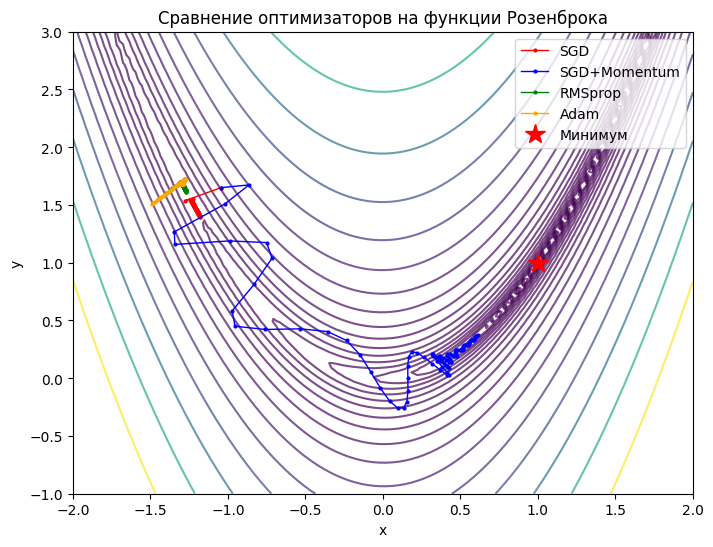

In [9]:
x0, y0 = -1.5, 1.5
steps = 100

# Словарь с оптимизаторами и их параметрами
optimizers = {
    'SGD': (torch.optim.SGD, {'lr': 0.001}),
    'SGD+Momentum': (torch.optim.SGD, {'lr': 0.001, 'momentum': 0.9}),
    'RMSprop': (torch.optim.RMSprop, {'lr': 0.01}),
    'Adam': (torch.optim.Adam, {'lr': 0.01})
}

trajectories = {}
for name, (opt_class, kwargs) in optimizers.items():
    xh, yh, fh = optimizer_trajectory(rosenbrock, x0, y0, opt_class, kwargs, steps)
    trajectories[name] = (xh, yh, fh)

# Построение
plt.figure(figsize=(8,6))
plt.contour(X, Y, Z_rosen, levels=np.logspace(-1, 3, 20), cmap='viridis', alpha=0.7)
colors = ['red', 'blue', 'green', 'orange']
for i, (name, (xh, yh, fh)) in enumerate(trajectories.items()):
    plt.plot(xh, yh, '.-', color=colors[i], linewidth=1, markersize=4, label=name)
plt.plot(1, 1, 'r*', markersize=15, label='Минимум')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Сравнение оптимизаторов на функции Розенброка')
plt.legend()
plt.show()

**Задание 5. Вопросы для анализа:**
- Какой оптимизатор быстрее достиг окрестности минимума?
- Как ведёт себя SGD без момента? Почему он "застревает" в овраге?
- Почему Adam и RMSprop работают лучше?
- Сравнить оптимизаторы по итоговому найденному значению минимизируемой функции.
- Сравнить времена работы (эффективность/производительность) оптимизаторов. Если на одинаковом количестве итераций они оказались примерно одинаковые, попробовать увеличить количество итераций так, чтобы 1-2 метода успели попасть в небольшую окрестность глобального минимума и сравнить методы по количеству этих итераций.

**Ответы:**
- Быстрее всех по числу итераций в eps-окрестность минимума попал `SGD+Momentum`.
- Обычный `SGD` без момента идёт медленно и зигзагообразно вдоль узкого оврага Розенброка, поэтому за тот же бюджет шагов не успевает дойти до окрестности минимума.
- `RMSprop` и `Adam` обычно устойчивее за счёт адаптации шага по координатам (и/или накопления моментов), но итог сильно зависит от подбора `lr` и стартовой точки.
- По нашему запуску минимальное финальное значение функции дало `SGD+Momentum`, затем `RMSprop`, затем `SGD`, а `Adam` с текущим `lr` оказался хуже и требует дополнительной настройки.
- По времени один шаг у методов сопоставим, но решает не только runtime, а и количество шагов до нужной точности: здесь `SGD+Momentum` оказался наиболее эффективным по качеству/скорости сходимости.

In [10]:
import time

def benchmark_optimizer(func, x0, y0, optim_class, optim_kwargs, steps=1000, eps=0.05, target=(1.0, 1.0)):
    """
    Возвращает траекторию, финальное значение функции, время и число итераций до попадания в eps-окрестность target.
    """
    x = torch.tensor(x0, requires_grad=True, dtype=torch.float32)
    y = torch.tensor(y0, requires_grad=True, dtype=torch.float32)
    optimizer = optim_class([x, y], **optim_kwargs)

    x_hist, y_hist, f_hist = [], [], []
    iter_to_target = None

    start_time = time.perf_counter()
    for i in range(steps):
        optimizer.zero_grad()
        f = func(x, y)
        f.backward()
        optimizer.step()

        xi, yi, fi = x.item(), y.item(), f.item()
        x_hist.append(xi)
        y_hist.append(yi)
        f_hist.append(fi)

        if iter_to_target is None and abs(xi - target[0]) < eps and abs(yi - target[1]) < eps:
            iter_to_target = i + 1
    elapsed = time.perf_counter() - start_time

    return x_hist, y_hist, f_hist, iter_to_target, elapsed

Итоги сравнения оптимизаторов (Розенброк):
name           | final f(x,y) | iters to eps-neighborhood | time (s)
SGD            |     0.285966 | не достиг                |   0.4328
SGD+Momentum   |     0.000000 | 623                      |   0.4978
RMSprop        |     0.033299 | не достиг                |   0.5785
Adam           |     2.529132 | не достиг                |   0.6662


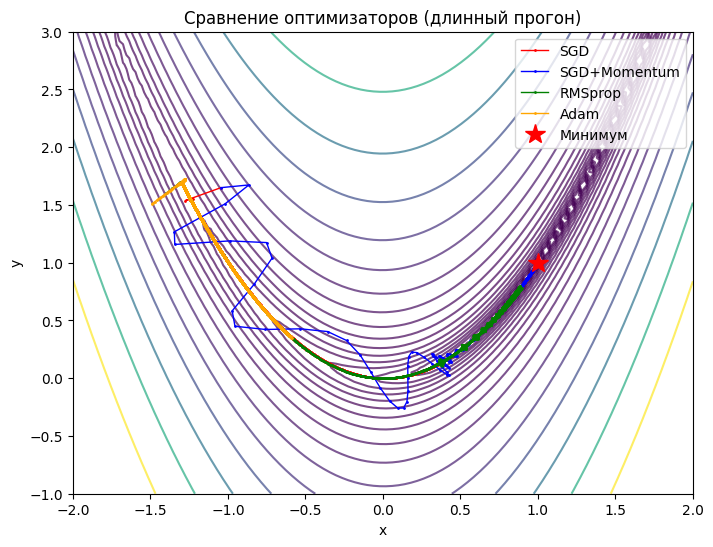

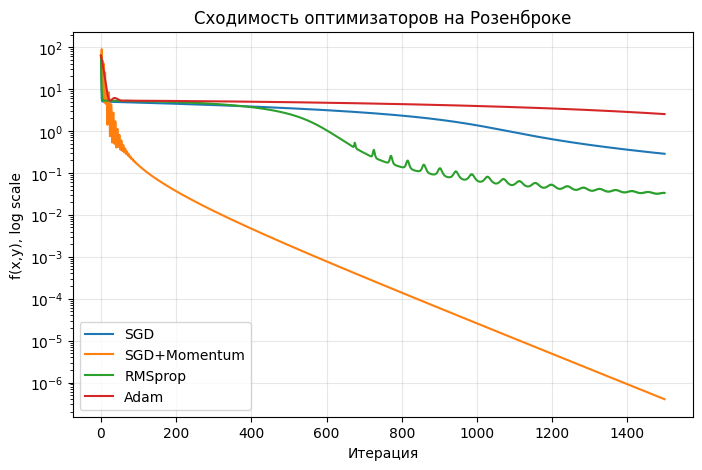

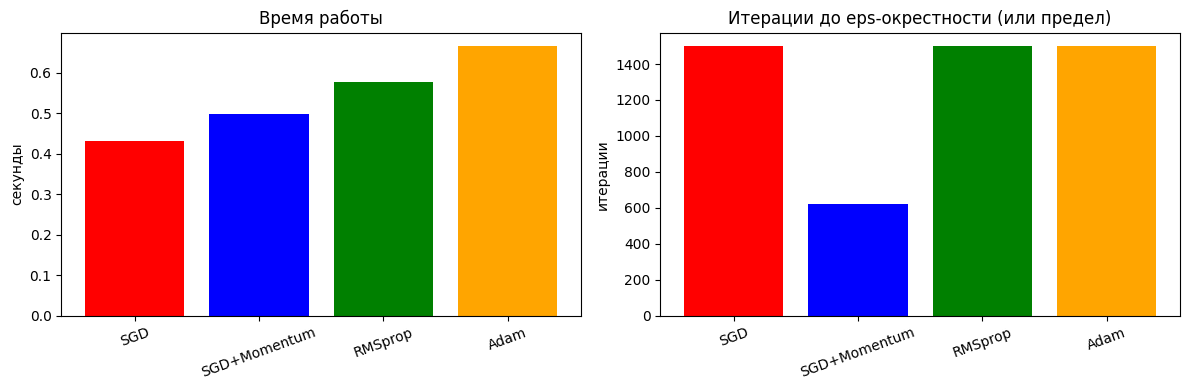

In [11]:
x0, y0 = -1.5, 1.5
steps = 1500
eps = 0.05

# Словарь с оптимизаторами и их параметрами
optimizers = {
    'SGD': (torch.optim.SGD, {'lr': 0.001}),
    'SGD+Momentum': (torch.optim.SGD, {'lr': 0.001, 'momentum': 0.9}),
    'RMSprop': (torch.optim.RMSprop, {'lr': 0.01}),
    'Adam': (torch.optim.Adam, {'lr': 0.01})
}

benchmark_results = []
trajectories_long = {}

for name, (opt_class, kwargs) in optimizers.items():
    xh, yh, fh, iters_hit, elapsed = benchmark_optimizer(
        rosenbrock, x0, y0, opt_class, kwargs, steps=steps, eps=eps, target=(1.0, 1.0)
    )
    trajectories_long[name] = (xh, yh, fh)
    benchmark_results.append((name, fh[-1], iters_hit, elapsed))

print('Итоги сравнения оптимизаторов (Розенброк):')
print('name           | final f(x,y) | iters to eps-neighborhood | time (s)')
for name, f_final, iters_hit, elapsed in benchmark_results:
    hit_str = str(iters_hit) if iters_hit is not None else 'не достиг'
    print(f'{name:14s} | {f_final:12.6f} | {hit_str:24s} | {elapsed:8.4f}')

# 1) Траектории на контурном графике
plt.figure(figsize=(8, 6))
plt.contour(X, Y, Z_rosen, levels=np.logspace(-1, 3, 20), cmap='viridis', alpha=0.7)
colors = ['red', 'blue', 'green', 'orange']
for i, (name, (xh, yh, fh)) in enumerate(trajectories_long.items()):
    plt.plot(xh, yh, '.-', color=colors[i], linewidth=1, markersize=2, label=name)
plt.plot(1, 1, 'r*', markersize=15, label='Минимум')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Сравнение оптимизаторов (длинный прогон)')
plt.legend()
plt.show()

# 2) Кривые потерь
plt.figure(figsize=(8, 5))
for name, (xh, yh, fh) in trajectories_long.items():
    plt.semilogy(fh, label=name)
plt.xlabel('Итерация')
plt.ylabel('f(x,y), log scale')
plt.title('Сходимость оптимизаторов на Розенброке')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# 3) Время и число итераций до окрестности минимума
names = [r[0] for r in benchmark_results]
times = [r[3] for r in benchmark_results]
iters = [r[2] if r[2] is not None else steps for r in benchmark_results]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(names, times, color=['red', 'blue', 'green', 'orange'])
axes[0].set_title('Время работы')
axes[0].set_ylabel('секунды')
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(names, iters, color=['red', 'blue', 'green', 'orange'])
axes[1].set_title('Итерации до eps-окрестности (или предел)')
axes[1].set_ylabel('итерации')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

### 4.2 Анимация траекторий (дополнительно)
Для наглядности можно создать анимацию движения точек. Ниже приведён код для создания GIF-анимации с помощью matplotlib.animation. Запустите эту ячейку, чтобы увидеть, как оптимизаторы "шагают" к минимуму.

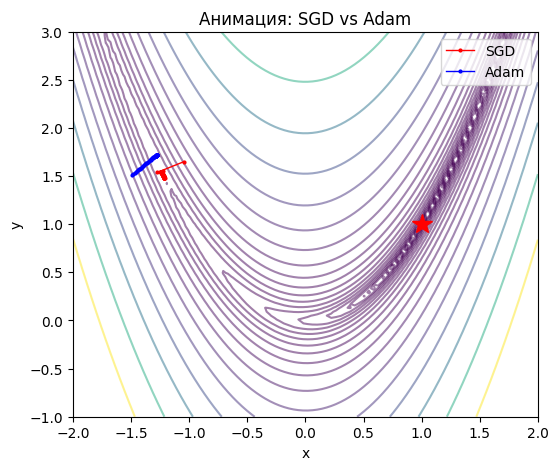

In [12]:
# Создаём анимацию для двух оптимизаторов: SGD и Adam
fig, ax = plt.subplots(figsize=(6,5))
ax.contour(X, Y, Z_rosen, levels=np.logspace(-1, 3, 20), cmap='viridis', alpha=0.5)
ax.plot(1, 1, 'r*', markersize=15)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Анимация: SGD vs Adam')

line_sgd, = ax.plot([], [], 'r.-', lw=1, markersize=4, label='SGD')
line_adam, = ax.plot([], [], 'b.-', lw=1, markersize=4, label='Adam')
ax.legend()

# Получаем траектории (первые steps точек)
steps_anim = 50  # возьмём первые 50 шагов для анимации
x_sgd, y_sgd = trajectories['SGD'][0][:steps_anim], trajectories['SGD'][1][:steps_anim]
x_adam, y_adam = trajectories['Adam'][0][:steps_anim], trajectories['Adam'][1][:steps_anim]

def init():
    line_sgd.set_data([], [])
    line_adam.set_data([], [])
    return line_sgd, line_adam

def animate(i):
    line_sgd.set_data(x_sgd[:i+1], y_sgd[:i+1])
    line_adam.set_data(x_adam[:i+1], y_adam[:i+1])
    return line_sgd, line_adam

anim = animation.FuncAnimation(fig, animate, init_func=init, frames=steps_anim, interval=100, blit=True)

# Показываем анимацию без требования ffmpeg
try:
    HTML(anim.to_html5_video())
except RuntimeError:
    HTML(anim.to_jshtml())

## 5. Влияние скорости обучения (learning rate) на сходимость

Проведём эксперимент: зафиксируем начальную точку (-1.5, 1.5) и оптимизатор SGD (без момента). Будем менять learning rate: очень маленький (0.0001), средний (0.001), большой (0.01) и слишком большой (0.1). Наблюдаем поведение.

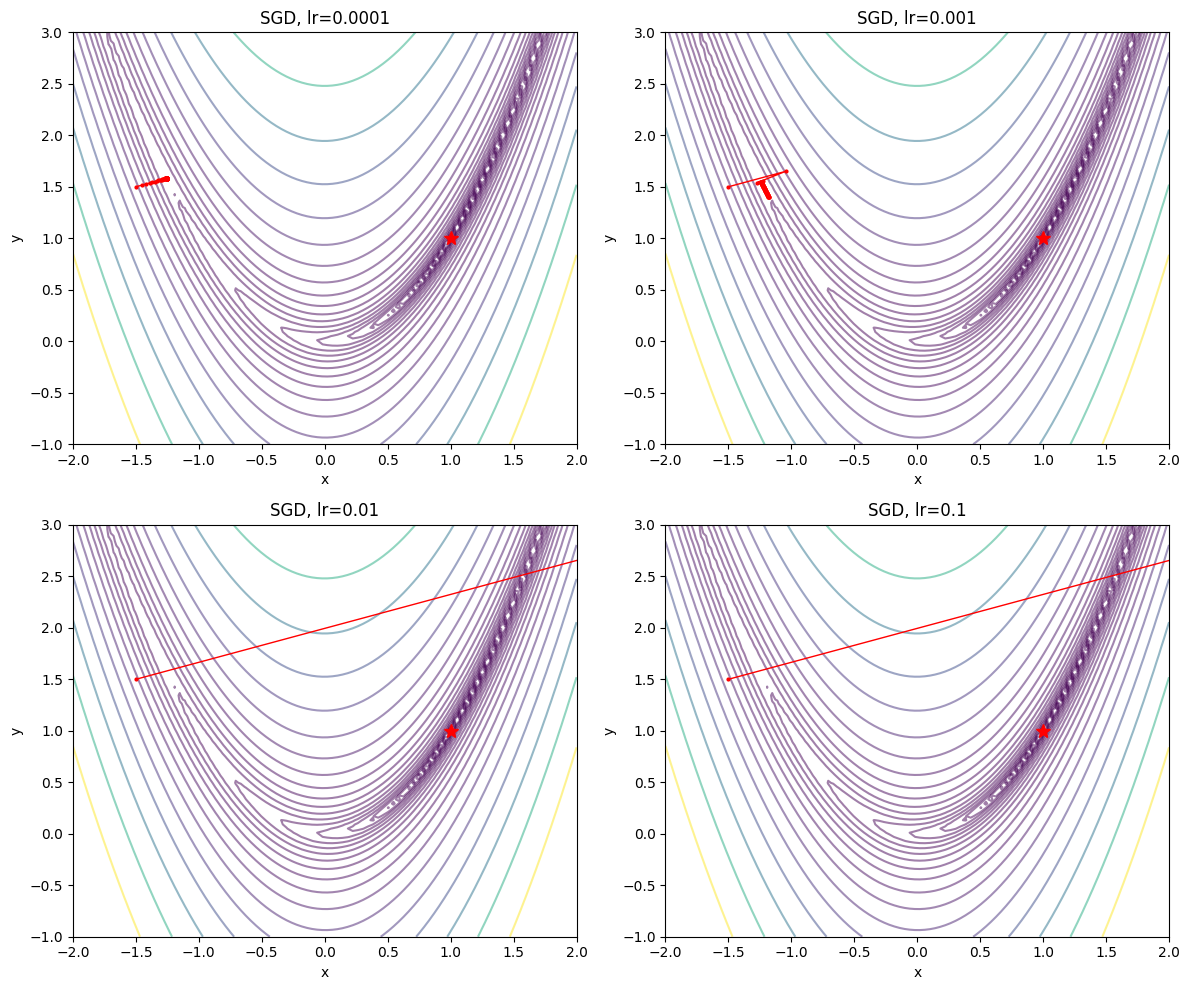

In [13]:
lrs_to_try = [0.0001, 0.001, 0.01, 0.1]
x0, y0 = -1.5, 1.5
steps = 100

plt.figure(figsize=(12,10))

for i, lr in enumerate(lrs_to_try):
    xh, yh, fh = sgd_trajectory(rosenbrock, x0, y0, lr, steps)
    plt.subplot(2,2,i+1)
    plt.contour(X, Y, Z_rosen, levels=np.logspace(-1, 3, 20), cmap='viridis', alpha=0.5)
    plt.plot(xh, yh, 'r.-', markersize=4, linewidth=1)
    plt.plot(1, 1, 'r*', markersize=10)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(f'SGD, lr={lr}')
    plt.xlim(-2,2)
    plt.ylim(-1,3)

plt.tight_layout()
plt.show()

**Обсуждение:**
- При очень маленьком LR (0.0001) алгоритм не успевает дойти до минимума за 100 шагов.
- При LR=0.001 траектория медленно сползает в овраг и движется к минимуму.
- При LR=0.01 шаги больше, но из-за оврага траектория может "перепрыгивать" и колебаться.
- При LR=0.1 градиентный спуск расходится: шаги становятся настолько большими, что точка улетает за пределы графика. Это иллюстрация "взрыва градиентов" (хотя здесь не градиенты взрываются, а слишком большой шаг).

**Задание 6.** Для функции Химмельблау и начальной точки (0, 0) подберите такое значение learning rate для SGD, чтобы алгоритм сошёлся к одному из минимумов, но при этом траектория была "интересной" (например, с колебаниями). Попробуйте также очень большое LR и посмотрите, куда улетает точка.

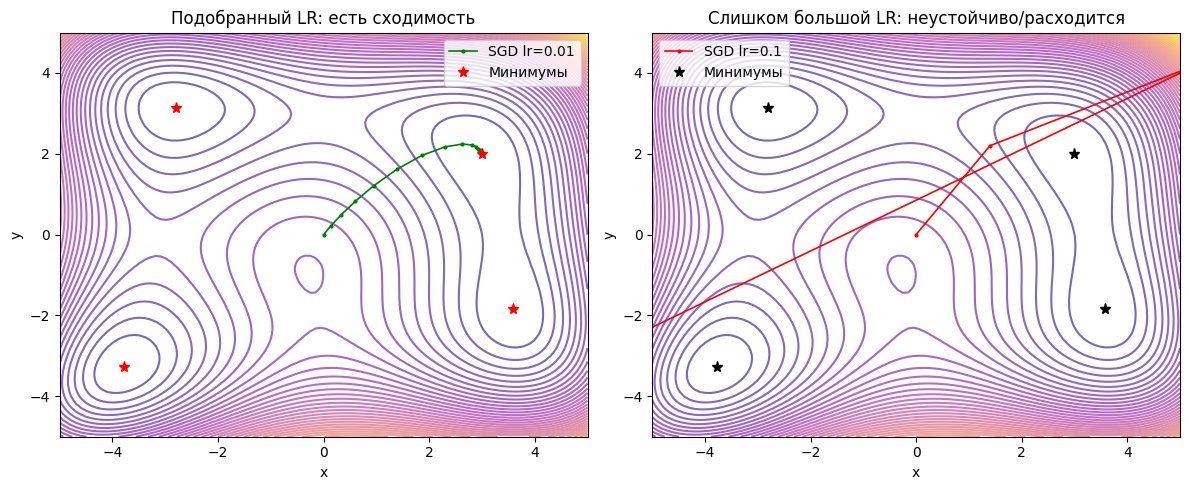

Для lr=0.01 последняя точка: (3.000, 2.000), ближайший минимум: (3.000, 2.000), расстояние=0.0000
Для lr=0.1 расходится: True, число сохранённых шагов: 4


In [14]:
# Ваш эксперимент с Химмельблау и разными LR
x0_h, y0_h = 0.0, 0.0
steps_h = 120
lr_good = 0.01
lr_bad = 0.1

def sgd_trajectory_safe(func, x0, y0, lr=0.01, steps=100):
    x = torch.tensor(x0, requires_grad=True, dtype=torch.float32)
    y = torch.tensor(y0, requires_grad=True, dtype=torch.float32)
    x_hist, y_hist, f_hist = [], [], []
    diverged = False

    for _ in range(steps):
        f = func(x, y)
        if not torch.isfinite(f):
            diverged = True
            break

        x_hist.append(x.item())
        y_hist.append(y.item())
        f_hist.append(f.item())

        f.backward()
        with torch.no_grad():
            x -= lr * x.grad
            y -= lr * y.grad

        if (not torch.isfinite(x)) or (not torch.isfinite(y)) or abs(x.item()) > 1e4 or abs(y.item()) > 1e4:
            diverged = True
            break

        x.grad.zero_()
        y.grad.zero_()

    return x_hist, y_hist, f_hist, diverged

xh_good, yh_good, fh_good, div_good = sgd_trajectory_safe(himmelblau, x0_h, y0_h, lr=lr_good, steps=steps_h)
xh_bad, yh_bad, fh_bad, div_bad = sgd_trajectory_safe(himmelblau, x0_h, y0_h, lr=lr_bad, steps=steps_h)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].contour(X_h, Y_h, Z_himm, levels=50, cmap='plasma', alpha=0.6)
axes[0].plot(xh_good, yh_good, 'g.-', markersize=4, linewidth=1.2, label=f'SGD lr={lr_good}')
for i, (mx, my) in enumerate(minima):
    label = 'Минимумы' if i == 0 else None
    axes[0].plot(mx, my, 'r*', markersize=8, label=label)
axes[0].set_title('Подобранный LR: есть сходимость')
axes[0].set_xlim(-5, 5)
axes[0].set_ylim(-5, 5)
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].legend()

axes[1].contour(X_h, Y_h, Z_himm, levels=50, cmap='plasma', alpha=0.6)
axes[1].plot(xh_bad, yh_bad, 'r.-', markersize=4, linewidth=1.2, label=f'SGD lr={lr_bad}')
for i, (mx, my) in enumerate(minima):
    label = 'Минимумы' if i == 0 else None
    axes[1].plot(mx, my, 'k*', markersize=8, label=label)
axes[1].set_title('Слишком большой LR: неустойчиво/расходится')
axes[1].set_xlim(-5, 5)
axes[1].set_ylim(-5, 5)
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].legend()

plt.tight_layout()
plt.show()

if len(xh_good) > 0:
    (mx, my), dist = nearest_himmelblau_minimum(xh_good[-1], yh_good[-1], minima)
    print(f'Для lr={lr_good} последняя точка: ({xh_good[-1]:.3f}, {yh_good[-1]:.3f}), ближайший минимум: ({mx:.3f}, {my:.3f}), расстояние={dist:.4f}')
print(f'Для lr={lr_bad} расходится: {div_bad}, число сохранённых шагов: {len(xh_bad)}')

## **6. Итоги занятия**

* Что нового узнали? (навыки/умения/знания).

На практике я научился визуализировать сложные ландшафты функций потерь (3D и контуры), запускать SGD вручную и сравнивать разные оптимизаторы по траектории, скорости и качеству сходимости.
